# Intro

Autoencoders:

* Auto - self
* Encode - convert into a different form (typically simpler or reduced-dimensional)
* Autoencoder - a system that teaches itself how to encode information

Loss:

* We use MSE Loss function to claculate error between input and output.
* We can also use cross-entropy if the data values are probabilities or scaled [0 1]

Usage:

* Data compression or dimension-reduction
* Data clearning (denoising, despeckling, occlusion)
* Feature extraction
* Anomaly/fraud detection
* Pretraining deep or complex models

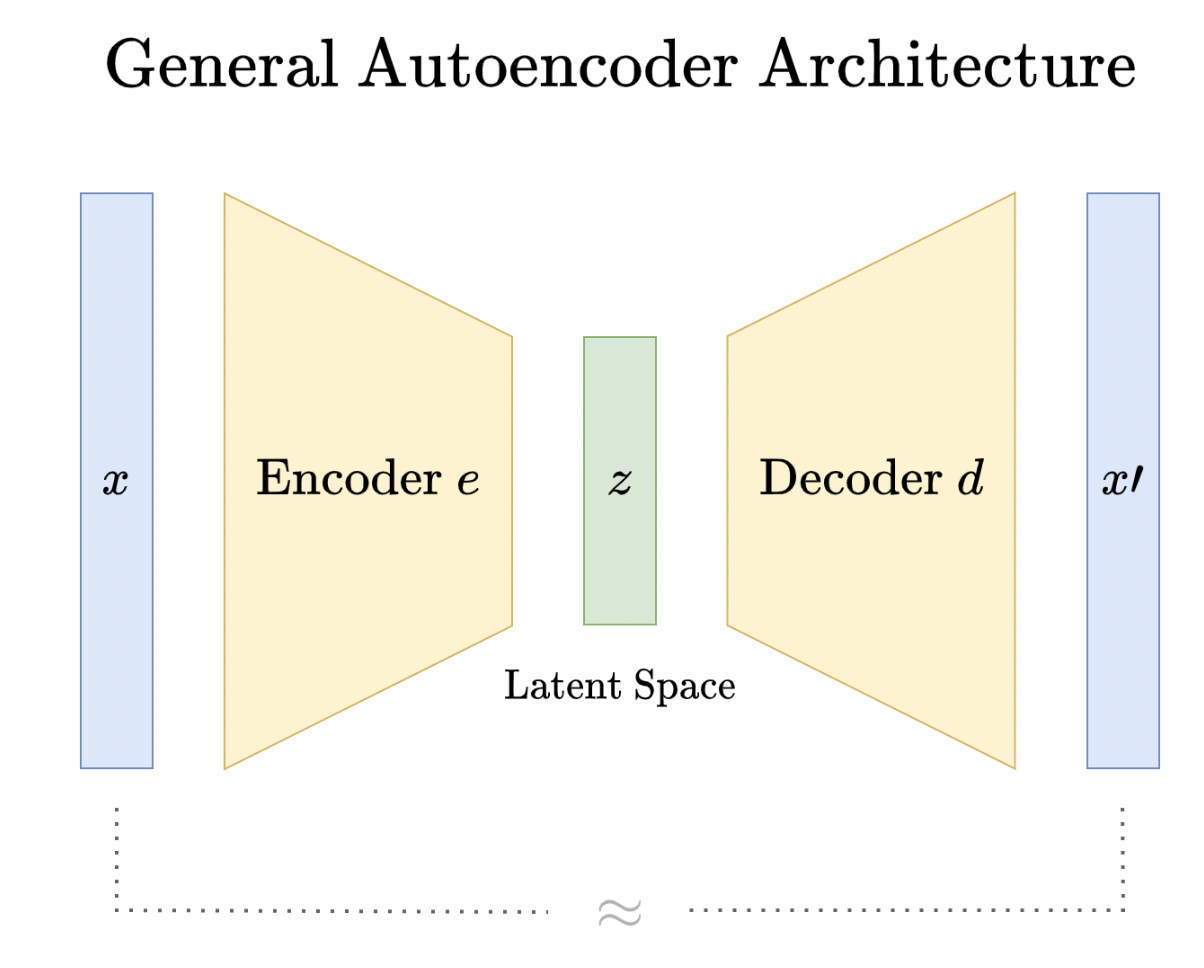

Layer Sizes:

$$ x > e > z $$

# Denoising MNIST

## Data

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

data = data[:,1:]

data = torch.tensor(data, dtype = torch.float)

# normalization
data = data / torch.max(data)

data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

## Model

In [3]:
def CreateAENet():

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)

      # encoder layer
      self.enc = nn.Linear(250, 50)

      # latent layer
      self.lat = nn.Linear(50, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet()

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

## First Spin

In [4]:
net, loss_fn, optimizer = CreateAENet()

X = data[:5, :]
y_hat = net(X)

print(X.shape)
print(y_hat.shape)

torch.Size([5, 784])
torch.Size([5, 784])


Let's see what the model did

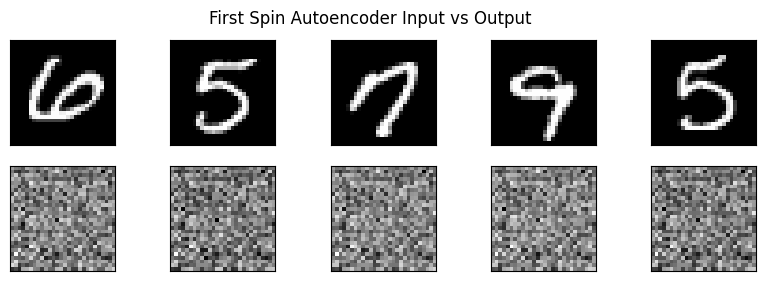

In [5]:
fig, axs = plt.subplots(2,5,figsize = (10,3))

for i in range(5):
  axs[0, i].imshow(X[i, :].view(28,28).detach(), cmap = 'gray')
  axs[1, i].imshow(y_hat[i, :].view(28,28).detach(), cmap = 'gray')
  axs[0, i].set_xticks([]), axs[0, i].set_yticks([])
  axs[1, i].set_xticks([]), axs[1, i].set_yticks([])

plt.suptitle('First Spin Autoencoder Input vs Output')
plt.show()

## Train

We don't do minibatches here so training loop is way shorter

In [6]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateAENet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [7]:
losses, net = ModelTrain(10000, True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.03
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.02
Epoch: 700 | Loss: 0.02
Epoch: 800 | Loss: 0.02
Epoch: 900 | Loss: 0.02
Epoch: 1000 | Loss: 0.02
Epoch: 1100 | Loss: 0.02
Epoch: 1200 | Loss: 0.02
Epoch: 1300 | Loss: 0.02
Epoch: 1400 | Loss: 0.01
Epoch: 1500 | Loss: 0.02
Epoch: 1600 | Loss: 0.01
Epoch: 1700 | Loss: 0.01
Epoch: 1800 | Loss: 0.01
Epoch: 1900 | Loss: 0.01
Epoch: 2000 | Loss: 0.01
Epoch: 2100 | Loss: 0.01
Epoch: 2200 | Loss: 0.01
Epoch: 2300 | Loss: 0.01
Epoch: 2400 | Loss: 0.01
Epoch: 2500 | Loss: 0.01
Epoch: 2600 | Loss: 0.01
Epoch: 2700 | Loss: 0.01
Epoch: 2800 | Loss: 0.01
Epoch: 2900 | Loss: 0.01
Epoch: 3000 | Loss: 0.01
Epoch: 3100 | Loss: 0.01
Epoch: 3200 | Loss: 0.01
Epoch: 3300 | Loss: 0.01
Epoch: 3400 | Loss: 0.01
Epoch: 3500 | Loss: 0.01
Epoch: 3600 | Loss: 0.01
Epoch: 3700 | Loss: 0.01
Epoch: 3800 | Loss: 0.01
Epoch: 3900 | Loss: 0.01
Epoch: 4000 

## Plot

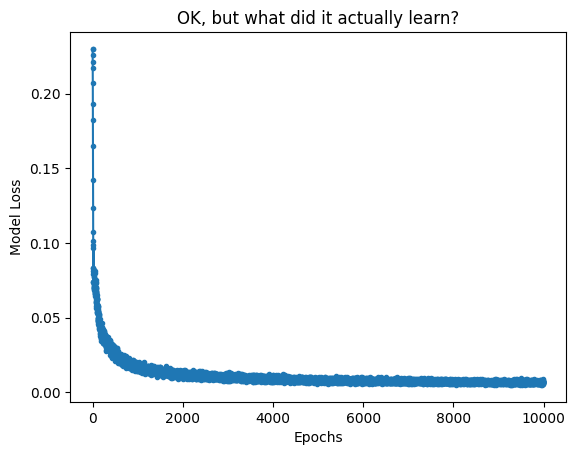

In [8]:
plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel('Model Loss')
plt.title('OK, but what did it actually learn?')
plt.show()

## Check Output

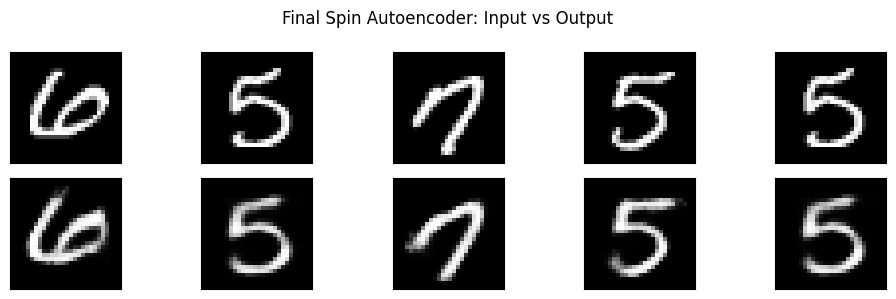

In [9]:
fig, axs = plt.subplots(2, 5, figsize=(10, 3))

# Wylosuj 5 różnych indeksów jednorazowo
rand_rows = torch.randint(0, X.shape[0], (5,))

for i, idx in enumerate(rand_rows):
    axs[0, i].imshow(X[idx].view(28, 28).detach(), cmap='gray')

    y_hat = net(X[idx])
    axs[1, i].imshow(y_hat.view(28, 28).detach(), cmap='gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Final Spin Autoencoder: Input vs Output')
plt.tight_layout()
plt.show()

## Add noise

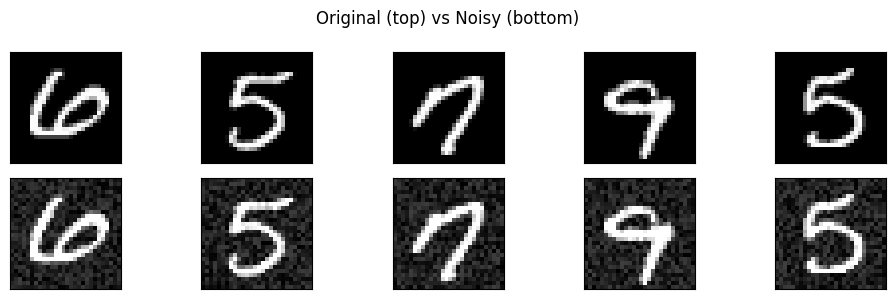

In [10]:
# grab a small set of images
X = data[:10, :]

# add noise
X_noise = X + torch.rand_like(X) / 4

# clip at 1
X_noise = torch.clamp(X_noise, 0, 1)

# show the noisy images
fig, axs = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (bottom)')
plt.tight_layout()
plt.show()


Let's now push the noisy data through the model

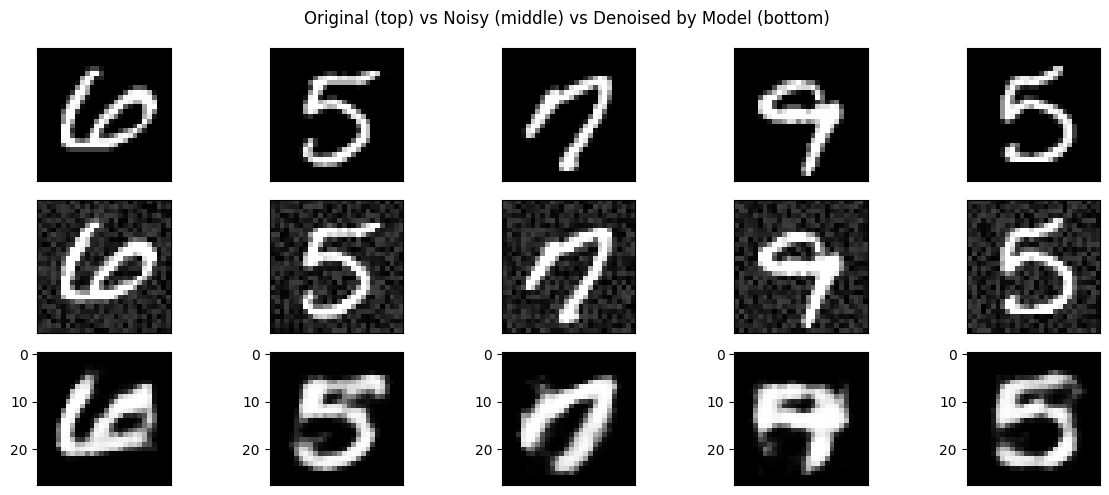

In [11]:
Y = net (X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (middle) vs Denoised by Model (bottom)')
plt.tight_layout()
plt.show()

---
---

# Additional Explorations

1) Because these are continuous data, mean-squared-error is the correct loss function. But I mentioned in the previous video that binary cross-entropy loss is *sometimes* used in autoencoders. Does the loss function make a difference for this problem? Why?

2) Change the number of units in the latent layer to 10. How does that affect the loss and denoising? Don't turn this into a full parametric experiment -- that's for the next video!

3) The code here picks samples randomly, which means many samples are skipped, and some could be repeated. Change the code so that the model goes through every item exactly once per epoch. The order should be randomized to avoid possible order effects. You'll probably want to reduce the number of epochs!

4) Is it necessary to normalize the data to a range of [0 1]? What are arguments for normalization, and arguments why it may not be critical (in this problem)?

5) The autoencoder did a pretty decent job at denoising the images. How far can you push this? Try adding more noise to the images and re-running the test code (you don't need to retrain the model). Is the autoencoder robust to a a larger amount of noise?


## Comparison of MSE Loss and BCE Loss

### Model

In [12]:
def CreateAENet(loss_fn):

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)
      # encoder layer
      self.enc = nn.Linear(250, 50)
      # latent layer
      self.lat = nn.Linear(50, 250)
      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet(nn.BCELoss)

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 torch.nn.modules.loss.BCELoss,
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

### BCELoss Run

In [13]:
def ModelTrain(epochs, verbose, loss_fn):
  net, loss_fn, optimizer = CreateAENet(loss_fn)

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, :]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [14]:
losses_BCE, net_BCE = ModelTrain(epochs = 10000, verbose = True, loss_fn = nn.BCELoss())

Epoch: 0 | Loss: 0.69
Epoch: 100 | Loss: 0.25
Epoch: 200 | Loss: 0.18
Epoch: 300 | Loss: 0.16
Epoch: 400 | Loss: 0.15
Epoch: 500 | Loss: 0.15
Epoch: 600 | Loss: 0.14
Epoch: 700 | Loss: 0.13
Epoch: 800 | Loss: 0.12
Epoch: 900 | Loss: 0.12
Epoch: 1000 | Loss: 0.12
Epoch: 1100 | Loss: 0.11
Epoch: 1200 | Loss: 0.11
Epoch: 1300 | Loss: 0.12
Epoch: 1400 | Loss: 0.10
Epoch: 1500 | Loss: 0.12
Epoch: 1600 | Loss: 0.11
Epoch: 1700 | Loss: 0.10
Epoch: 1800 | Loss: 0.10
Epoch: 1900 | Loss: 0.10
Epoch: 2000 | Loss: 0.09
Epoch: 2100 | Loss: 0.08
Epoch: 2200 | Loss: 0.09
Epoch: 2300 | Loss: 0.10
Epoch: 2400 | Loss: 0.10
Epoch: 2500 | Loss: 0.09
Epoch: 2600 | Loss: 0.09
Epoch: 2700 | Loss: 0.09
Epoch: 2800 | Loss: 0.10
Epoch: 2900 | Loss: 0.09
Epoch: 3000 | Loss: 0.09
Epoch: 3100 | Loss: 0.09
Epoch: 3200 | Loss: 0.09
Epoch: 3300 | Loss: 0.09
Epoch: 3400 | Loss: 0.09
Epoch: 3500 | Loss: 0.10
Epoch: 3600 | Loss: 0.09
Epoch: 3700 | Loss: 0.08
Epoch: 3800 | Loss: 0.09
Epoch: 3900 | Loss: 0.09
Epoch: 4000 

### Plots

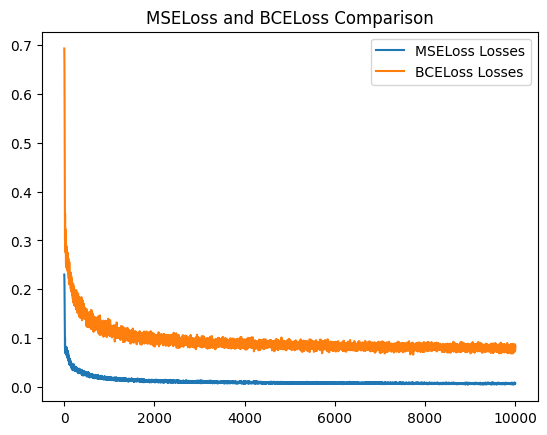

In [15]:
plt.plot(losses, label = 'MSELoss Losses')
plt.plot(losses_BCE, label = 'BCELoss Losses')
plt.legend()
plt.title('MSELoss and BCELoss Comparison')
plt.show()

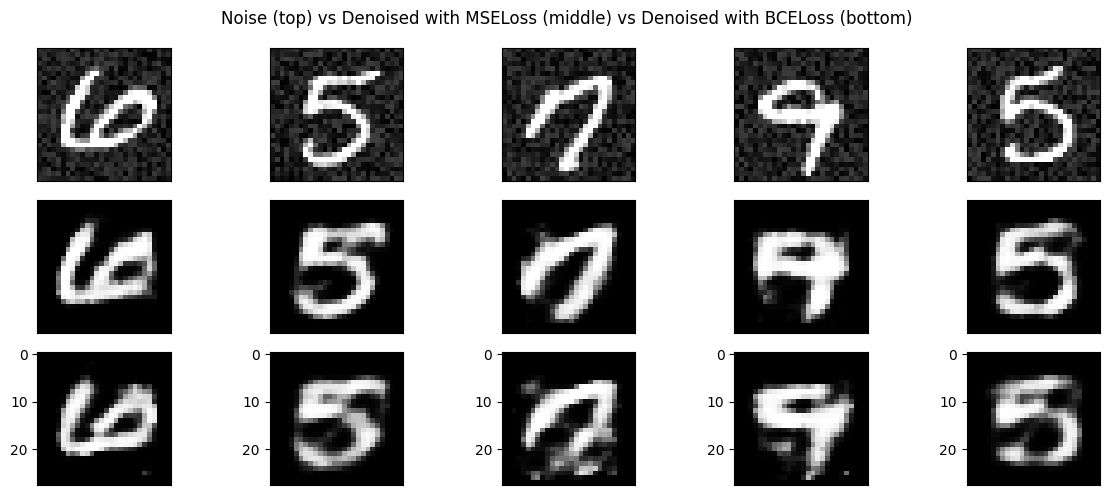

In [16]:
Y = net(X_noise)
Y_BCE = net_BCE(X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(Y[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y_BCE[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Noise (top) vs Denoised with MSELoss (middle) vs Denoised with BCELoss (bottom)')
plt.tight_layout()
plt.show()

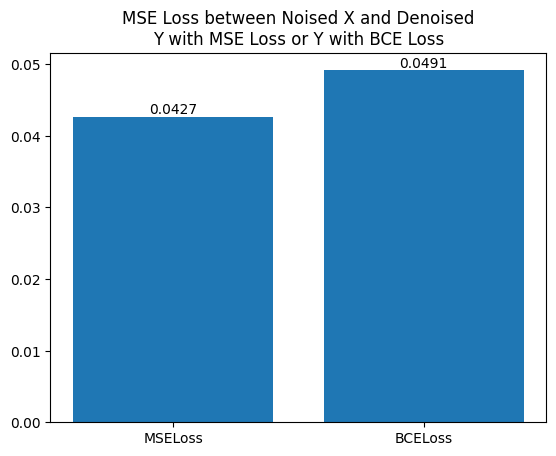

In [17]:
mse_MSE = torch.mean((Y - X)**2)
mse_BCE = torch.mean((Y_BCE - X)**2)

losses_values = [mse_MSE.item(), mse_BCE.item()]
plt.bar(range(2), losses_values)
for i, v in enumerate(losses_values):
  plt.text(i, v, f'{v:.4f}', ha = 'center', va = 'bottom')
plt.xticks(range(2), ['MSELoss', 'BCELoss'])
plt.title('MSE Loss between Noised X and Denoised\nY with MSE Loss or Y with BCE Loss')
plt.show()

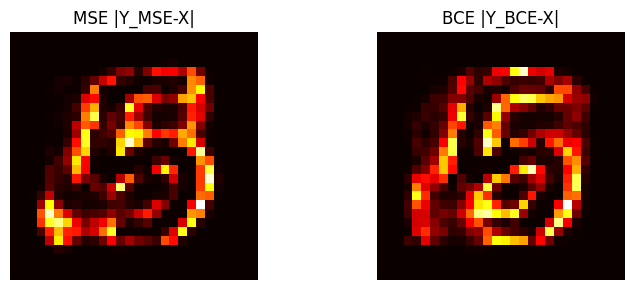

In [18]:
diff_MSE = torch.abs(Y - X)
diff_BCE = torch.abs(Y_BCE - X)

rand_row = np.random.randint(diff_MSE.shape[0])

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(diff_MSE[rand_row].view(28,28).cpu().detach(), cmap='hot')
plt.title("MSE |Y_MSE-X|")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(diff_BCE[rand_row].view(28,28).cpu().detach(), cmap='hot')
plt.title("BCE |Y_BCE-X|")
plt.axis('off')

plt.tight_layout()
plt.show()


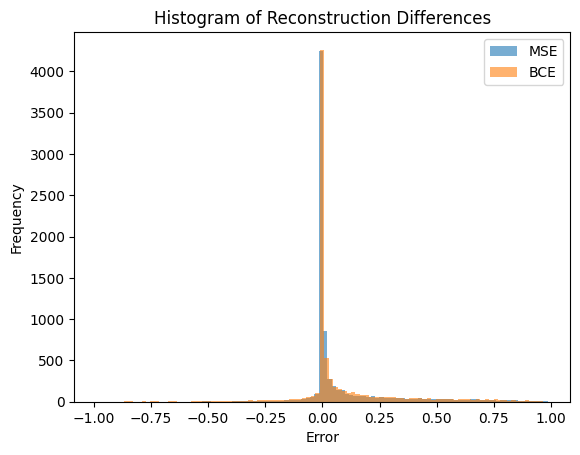

In [19]:
plt.hist((Y - X).flatten().cpu().detach(), bins=100, alpha=0.6, label='MSE')
plt.hist((Y_BCE - X).flatten().cpu().detach(), bins=100, alpha=0.6, label='BCE')
plt.legend()
plt.title("Histogram of Reconstruction Differences")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

### Conclusion

$$ MSE = \frac{1}{N}\sum_{i=1}^N (y_i - \overset{\wedge}{y_i})^2 $$

$$ BCE = -\frac{1}{N} \sum_{i=1}^N \Big[y_i log(\overset{\wedge}{y_i}) + (1 - y_i) log(1 - \overset{\wedge}{y_i})\Big]$$

* Data Type
  * MSE - continuous
  * BCE - binary / probabilistic

* Range
  * MSE - any
  * BCE - [0,1] after sigmoid

* Gradient
  * MSE - Linear
  * BCE - Non-Linear, dependent on logs

* Typical usage
  * MSE - Regression / Autoencoders
  * BCE - Binary Classification

MSELoss is better than BCELoss because:

1. Images are continuous values of pexels

3. BCE treats each pexel as probability of being 1, so it tries to guess 0 or 1 that's why denoising outputs more rough and with clipped values.

3. MSE looks on difference between pexels - so it learns how to reconstruct intensity, not only "if pexel is fired"

4. Gradient in MSE doesn't fade out, so it learns in more stable and faster manner

## Decrease latent layer neurons to 10

### Model

In [20]:
def CreateAENet():

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)

      # encoder layer
      self.enc = nn.Linear(250, 10)

      # latent layer
      self.lat = nn.Linear(10, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet()

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=10, bias=True)
   (lat): Linear(in_features=10, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

### Train

In [21]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateAENet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

### Decreased Latent space neurons Run

In [22]:
losses_decreased, net_decreased = ModelTrain(epochs = 10000, verbose = True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.04
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.04
Epoch: 700 | Loss: 0.03
Epoch: 800 | Loss: 0.03
Epoch: 900 | Loss: 0.03
Epoch: 1000 | Loss: 0.03
Epoch: 1100 | Loss: 0.03
Epoch: 1200 | Loss: 0.03
Epoch: 1300 | Loss: 0.03
Epoch: 1400 | Loss: 0.03
Epoch: 1500 | Loss: 0.03
Epoch: 1600 | Loss: 0.03
Epoch: 1700 | Loss: 0.03
Epoch: 1800 | Loss: 0.03
Epoch: 1900 | Loss: 0.03
Epoch: 2000 | Loss: 0.03
Epoch: 2100 | Loss: 0.03
Epoch: 2200 | Loss: 0.02
Epoch: 2300 | Loss: 0.03
Epoch: 2400 | Loss: 0.02
Epoch: 2500 | Loss: 0.02
Epoch: 2600 | Loss: 0.03
Epoch: 2700 | Loss: 0.03
Epoch: 2800 | Loss: 0.03
Epoch: 2900 | Loss: 0.02
Epoch: 3000 | Loss: 0.02
Epoch: 3100 | Loss: 0.02
Epoch: 3200 | Loss: 0.03
Epoch: 3300 | Loss: 0.02
Epoch: 3400 | Loss: 0.03
Epoch: 3500 | Loss: 0.03
Epoch: 3600 | Loss: 0.03
Epoch: 3700 | Loss: 0.02
Epoch: 3800 | Loss: 0.03
Epoch: 3900 | Loss: 0.02
Epoch: 4000 

### Plots

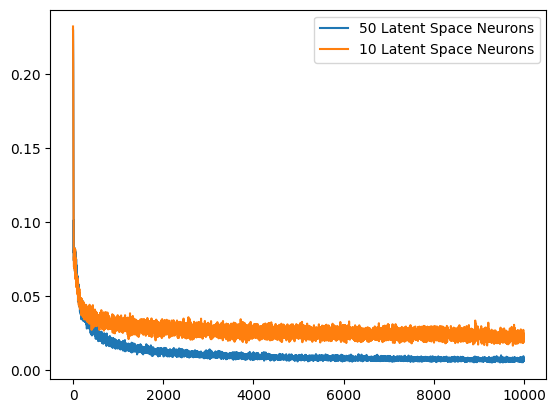

In [23]:
plt.plot(losses, label = '50 Latent Space Neurons')
plt.plot(losses_decreased, label = '10 Latent Space Neurons')
plt.legend()
plt.show()

### Conclusion

10 neurons performed worse than 50 in latent space. In next notebook we'll conduct thorough experiment for which latent layer neurons count is the best.

## Random Samples without Return

Original Train Loop picks samples randomly, which means many samples are skipped, and some could be repeated. New code will randomly pick without return.

### Model

In [24]:
def CreateAENet():

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)

      # encoder layer
      self.enc = nn.Linear(250, 50)

      # latent layer
      self.lat = nn.Linear(50, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet()

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

### Train

In [25]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateAENet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32, replace = False)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [26]:
losses_no_replace, net_decreased_no_replace = ModelTrain(epochs = 10000, verbose = True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.04
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.02
Epoch: 700 | Loss: 0.02
Epoch: 800 | Loss: 0.02
Epoch: 900 | Loss: 0.02
Epoch: 1000 | Loss: 0.02
Epoch: 1100 | Loss: 0.02
Epoch: 1200 | Loss: 0.02
Epoch: 1300 | Loss: 0.02
Epoch: 1400 | Loss: 0.01
Epoch: 1500 | Loss: 0.01
Epoch: 1600 | Loss: 0.01
Epoch: 1700 | Loss: 0.01
Epoch: 1800 | Loss: 0.02
Epoch: 1900 | Loss: 0.01
Epoch: 2000 | Loss: 0.01
Epoch: 2100 | Loss: 0.01
Epoch: 2200 | Loss: 0.01
Epoch: 2300 | Loss: 0.01
Epoch: 2400 | Loss: 0.01
Epoch: 2500 | Loss: 0.01
Epoch: 2600 | Loss: 0.01
Epoch: 2700 | Loss: 0.01
Epoch: 2800 | Loss: 0.01
Epoch: 2900 | Loss: 0.01
Epoch: 3000 | Loss: 0.01
Epoch: 3100 | Loss: 0.01
Epoch: 3200 | Loss: 0.01
Epoch: 3300 | Loss: 0.01
Epoch: 3400 | Loss: 0.01
Epoch: 3500 | Loss: 0.01
Epoch: 3600 | Loss: 0.01
Epoch: 3700 | Loss: 0.01
Epoch: 3800 | Loss: 0.01
Epoch: 3900 | Loss: 0.01
Epoch: 4000 

### Plots

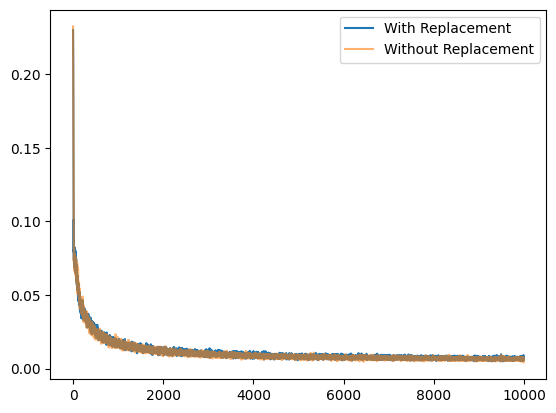

In [27]:
plt.plot(losses, label = 'With Replacement')
plt.plot(losses_no_replace, label = 'Without Replacement', alpha = .6)
plt.legend()
plt.show()

### Conclusion

There is practically no difference between training on images with and without replacement.

## Normalized vs Non-normalized Data

### Data

In [28]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

data = data[:,1:]

data = torch.tensor(data, dtype = torch.float)

data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

### Model

In [29]:
def CreateAENet():

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)

      # encoder layer
      self.enc = nn.Linear(250, 50)

      # latent layer
      self.lat = nn.Linear(50, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet()

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

### Train

In [30]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateAENet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [31]:
losses_non_norm, net_non_norm = ModelTrain(epochs = 10000, verbose = True)

Epoch: 0 | Loss: 6198.01
Epoch: 100 | Loss: 7217.63
Epoch: 200 | Loss: 6311.34
Epoch: 300 | Loss: 7195.07
Epoch: 400 | Loss: 7335.61
Epoch: 500 | Loss: 7079.19
Epoch: 600 | Loss: 6925.86
Epoch: 700 | Loss: 7184.26
Epoch: 800 | Loss: 7614.19
Epoch: 900 | Loss: 7078.55
Epoch: 1000 | Loss: 7572.05
Epoch: 1100 | Loss: 7231.79
Epoch: 1200 | Loss: 7035.80
Epoch: 1300 | Loss: 6808.37
Epoch: 1400 | Loss: 8028.30
Epoch: 1500 | Loss: 7035.71
Epoch: 1600 | Loss: 7037.77
Epoch: 1700 | Loss: 6586.69
Epoch: 1800 | Loss: 8145.12
Epoch: 1900 | Loss: 6973.45
Epoch: 2000 | Loss: 7176.73
Epoch: 2100 | Loss: 7241.44
Epoch: 2200 | Loss: 7582.49
Epoch: 2300 | Loss: 7248.38
Epoch: 2400 | Loss: 7220.70
Epoch: 2500 | Loss: 6839.75
Epoch: 2600 | Loss: 6410.42
Epoch: 2700 | Loss: 7073.83
Epoch: 2800 | Loss: 8238.63
Epoch: 2900 | Loss: 7233.55
Epoch: 3000 | Loss: 7188.92
Epoch: 3100 | Loss: 6985.09
Epoch: 3200 | Loss: 6918.07
Epoch: 3300 | Loss: 7214.94
Epoch: 3400 | Loss: 8003.84
Epoch: 3500 | Loss: 7359.92
Epoc

### Plots

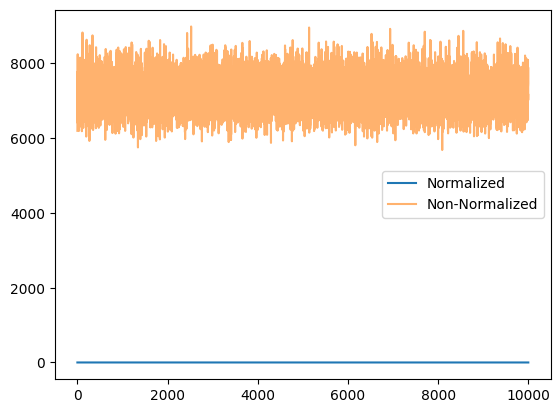

In [32]:
plt.plot(losses, label = 'Normalized')
plt.plot(losses_non_norm, label = 'Non-Normalized', alpha = .6)
plt.legend()
plt.show()

### Conclusion

In our situation data normalization is crucial because:

* Pixel values in MNIST go from 0 to 255. Without normalization, MSE term $(y - \overset{\wedge}{y})^2 $ becomes huge $\rightarrow$ gradients explode $\rightarrow$ training unstable

* Normalizing to [0,1] keeps all values small, so:
  * gradeints stay reasonable
  * training is stable
  * loss values make sense

## Test on more noise

### Data

In [33]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

data = data[:,1:]

data = torch.tensor(data, dtype = torch.float)

# normalization
data = data / torch.max(data)

data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

### Model

In [34]:
def CreateAENet():

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, 250)

      # encoder layer
      self.enc = nn.Linear(250, 50)

      # latent layer
      self.lat = nn.Linear(50, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet()

(AENet(
   (input): Linear(in_features=784, out_features=250, bias=True)
   (enc): Linear(in_features=250, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

### Train

In [35]:
X_noise.shape

torch.Size([10, 784])

In [36]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateAENet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [37]:
losses, net = ModelTrain(epochs = 10000, verbose = True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.03
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.02
Epoch: 700 | Loss: 0.02
Epoch: 800 | Loss: 0.02
Epoch: 900 | Loss: 0.02
Epoch: 1000 | Loss: 0.02
Epoch: 1100 | Loss: 0.02
Epoch: 1200 | Loss: 0.01
Epoch: 1300 | Loss: 0.01
Epoch: 1400 | Loss: 0.01
Epoch: 1500 | Loss: 0.01
Epoch: 1600 | Loss: 0.02
Epoch: 1700 | Loss: 0.01
Epoch: 1800 | Loss: 0.01
Epoch: 1900 | Loss: 0.01
Epoch: 2000 | Loss: 0.01
Epoch: 2100 | Loss: 0.01
Epoch: 2200 | Loss: 0.01
Epoch: 2300 | Loss: 0.01
Epoch: 2400 | Loss: 0.01
Epoch: 2500 | Loss: 0.01
Epoch: 2600 | Loss: 0.01
Epoch: 2700 | Loss: 0.01
Epoch: 2800 | Loss: 0.01
Epoch: 2900 | Loss: 0.01
Epoch: 3000 | Loss: 0.01
Epoch: 3100 | Loss: 0.01
Epoch: 3200 | Loss: 0.01
Epoch: 3300 | Loss: 0.01
Epoch: 3400 | Loss: 0.01
Epoch: 3500 | Loss: 0.01
Epoch: 3600 | Loss: 0.01
Epoch: 3700 | Loss: 0.01
Epoch: 3800 | Loss: 0.01
Epoch: 3900 | Loss: 0.01
Epoch: 4000 

### Add Noise

Let's make noise 8 times more intensive

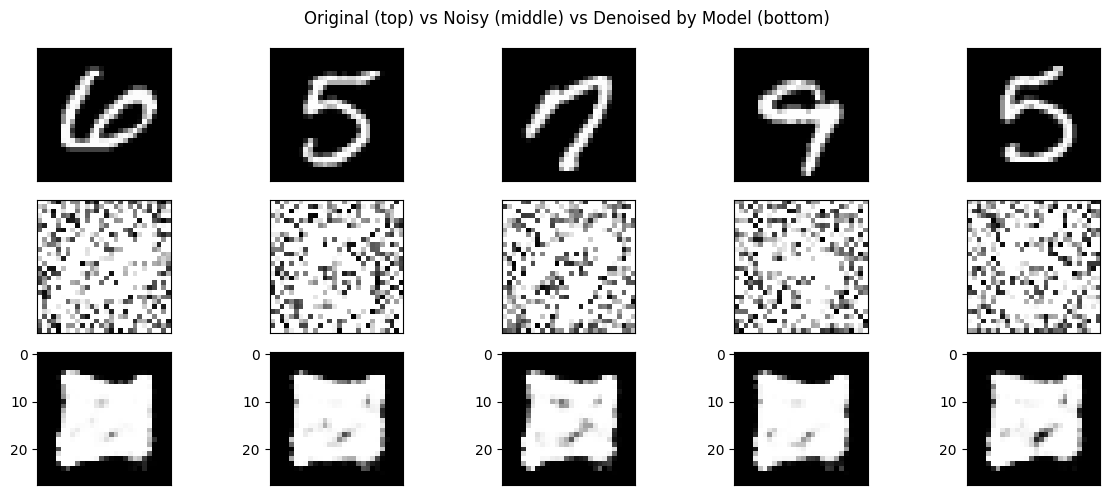

In [38]:
# grab a small set of images
X = data[:10, :]

# add noise
X_noise = X + torch.rand_like(X) * 2
# clip at 1
X_noise = torch.clamp(X_noise, 0, 1)

Y = net(X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (middle) vs Denoised by Model (bottom)')
plt.tight_layout()
plt.show()

That's too much, lets decrease noise 2 times

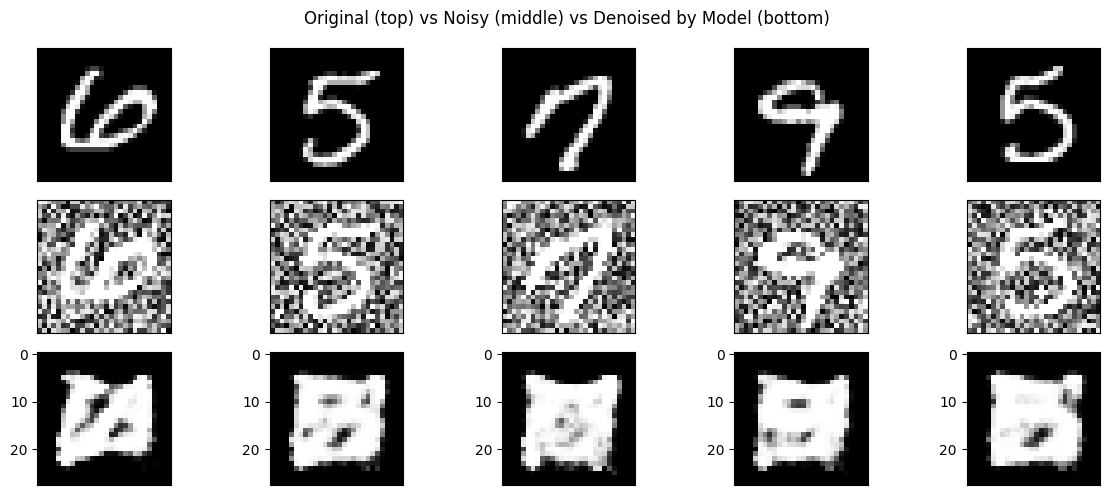

In [39]:
# grab a small set of images
X = data[:10, :]

# add noise
X_noise = X + torch.rand_like(X)
# clip at 1
X_noise = torch.clamp(X_noise, 0, 1)

Y = net(X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (middle) vs Denoised by Model (bottom)')
plt.tight_layout()
plt.show()

Still too much, let's decrease noise 2 times

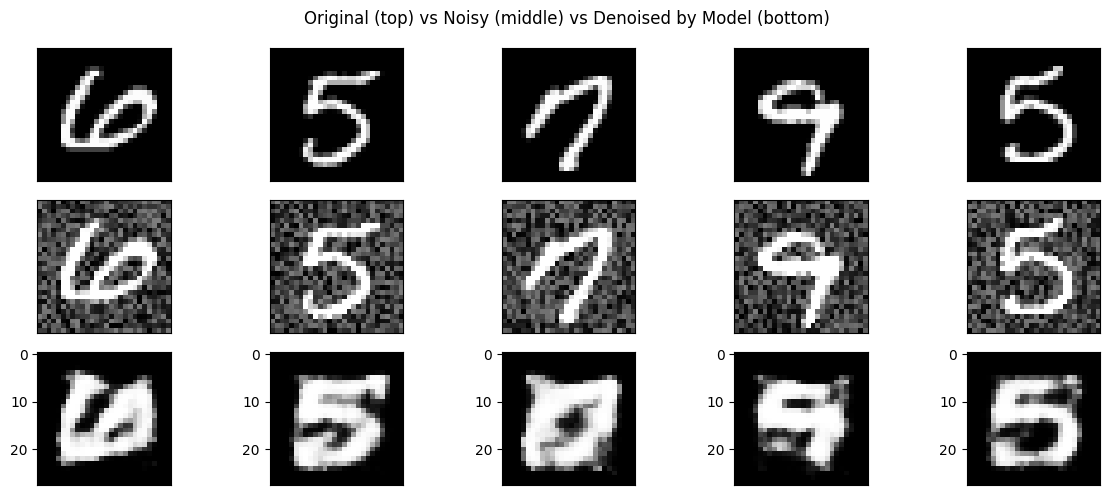

In [40]:
# grab a small set of images
X = data[:10, :]

# add noise
X_noise = X + torch.rand_like(X) / 2
# clip at 1
X_noise = torch.clamp(X_noise, 0, 1)

Y = net(X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (middle) vs Denoised by Model (bottom)')
plt.tight_layout()
plt.show()

That's a bit better but still sometimes it may be hard to understand denoised numbers. Let's decrease noise a bit more

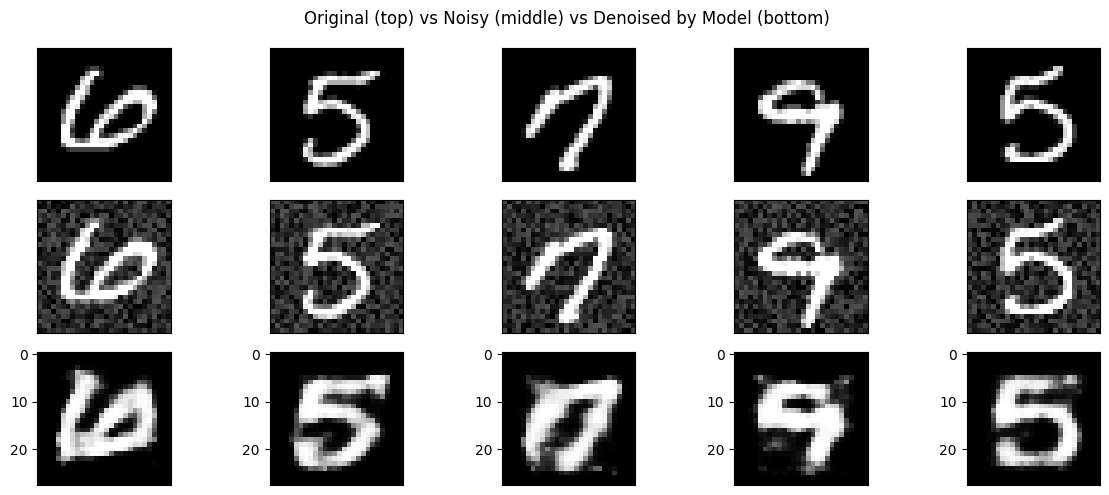

In [41]:
# grab a small set of images
X = data[:10, :]

# add noise
X_noise = X + torch.rand_like(X) / 3
# clip at 1
X_noise = torch.clamp(X_noise, 0, 1)

Y = net(X_noise)

# show the noisy images
fig, axs = plt.subplots(3, 5, figsize=(12, 5))

for i in range(5):
    axs[0, i].imshow(X[i].view(28, 28).detach(), cmap='gray')
    axs[1, i].imshow(X_noise[i].view(28, 28).detach(), cmap='gray')
    axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')

    axs[0, i].set_xticks([]); axs[0, i].set_yticks([])
    axs[1, i].set_xticks([]); axs[1, i].set_yticks([])
    axs[2, i].set_xticks([]); axs[1, i].set_yticks([])

plt.suptitle('Original (top) vs Noisy (middle) vs Denoised by Model (bottom)')
plt.tight_layout()
plt.show()

### Conclusion

Original noise was in range [0,0.25] and model performed very well on that.

We could increase the noise up to [0,0.33] and model would perform still pretty well but we could see sometimes that denoising damaged images a bit.

Noise [0, 0.5] is still handled by the model but significant damage is noticable after denoising.

Everything above 0.5 is not readible after denoising.

---
---

# Neurons Experiment

## Data

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [43]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

data = data[:,1:]

data = torch.tensor(data, dtype = torch.float)

# normalization
data = data / torch.max(data)

data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

## Model

In [44]:
def CreateAENet(enc_units, latent_units):

  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      # input layer
      self.input = nn.Linear(784, enc_units)

      # encoder layer
      self.enc = nn.Linear(enc_units, latent_units)

      # latent layer
      self.lat = nn.Linear(latent_units, 250)

      # decoder layer
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.enc(x))
      x = F.relu(self.lat(x))
      x = self.dec(x) # no relu!!!
      y = torch.sigmoid(x)
      return y

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
  return net, loss_fn, optimizer

CreateAENet(256, 50)

(AENet(
   (input): Linear(in_features=784, out_features=256, bias=True)
   (enc): Linear(in_features=256, out_features=50, bias=True)
   (lat): Linear(in_features=50, out_features=250, bias=True)
   (dec): Linear(in_features=250, out_features=784, bias=True)
 ),
 MSELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

## Train

In [45]:
def ModelTrain(enc_units, latent_units, epochs, verbose):
  net, loss_fn, optimizer = CreateAENet(enc_units, latent_units)

  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # select a random set of images
    random_idx = np.random.choice(data.shape[0], size = 32)
    X = data[random_idx, : ]

    # forward pass and loss
    y_hat = net(X)
    loss = loss_fn(y_hat, X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses

In [46]:
losses = ModelTrain(enc_units = 256, latent_units = 50, epochs = 100, verbose = True)

Epoch: 0 | Loss: 0.23


## Experiment

In [47]:
torch.linspace(10,500,12,dtype=int)

tensor([ 10,  54,  99, 143, 188, 232, 277, 321, 366, 410, 455, 500])

In [48]:
exp_enc_units = torch.linspace(10,500,12,dtype=int)
exp_lat_units = torch.linspace(5,100,8,dtype=int)

losses_store = torch.zeros(len(exp_enc_units), len(exp_lat_units))

done = 1

for idx_enc in range(len(exp_enc_units)):
  for idx_lat in range(len(exp_lat_units)):
    print(f'\n========= PROCESSING EXPERIMENT {done}/{len(exp_enc_units)*len(exp_lat_units)} ==========\n{exp_enc_units[idx_enc]} encoding layer units and {exp_lat_units[idx_lat]} latent layer units \n\n')
    losses = ModelTrain(enc_units = exp_enc_units[idx_enc],
                        latent_units = exp_lat_units[idx_lat],
                        epochs = 1000,
                        verbose = True)

    losses_store[idx_enc, idx_lat] = torch.mean(losses[-3:])
    done += 1


========= PROCESSING EXPERIMENT 1/96 ==========
10 encoding layer units and 5 latent layer units 


Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.06
Epoch: 300 | Loss: 0.05
Epoch: 400 | Loss: 0.05
Epoch: 500 | Loss: 0.05
Epoch: 600 | Loss: 0.05
Epoch: 700 | Loss: 0.05
Epoch: 800 | Loss: 0.04
Epoch: 900 | Loss: 0.04

========= PROCESSING EXPERIMENT 2/96 ==========
10 encoding layer units and 18 latent layer units 


Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.05
Epoch: 300 | Loss: 0.05
Epoch: 400 | Loss: 0.04
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.04
Epoch: 700 | Loss: 0.03
Epoch: 800 | Loss: 0.03
Epoch: 900 | Loss: 0.03

========= PROCESSING EXPERIMENT 3/96 ==========
10 encoding layer units and 32 latent layer units 


Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.05
Epoch: 300 | Loss: 0.05
Epoch: 400 | Loss: 0.04
Epoch: 500 | Loss: 0.04
Epoch: 600 | Loss: 0.04
Epoch: 700 | Loss: 0.04
Epoch: 800 | Loss: 0.04
Epoch

## Plot

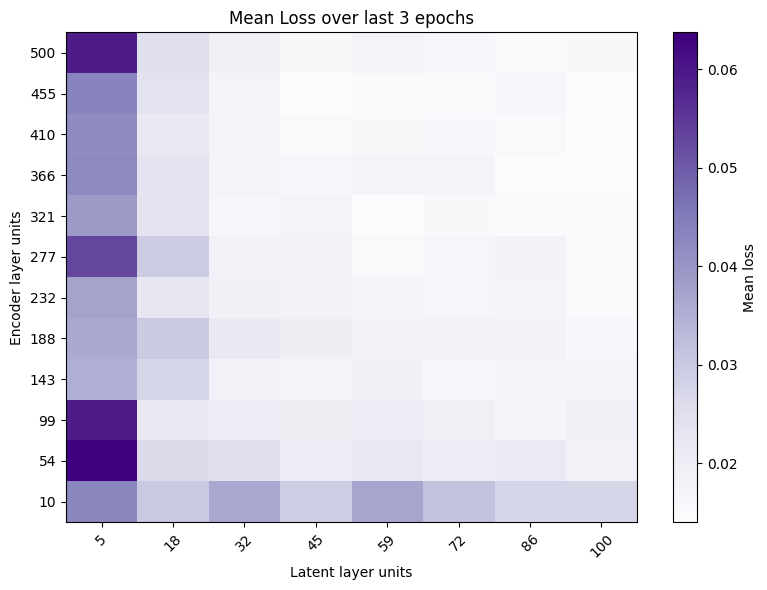

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Upewnij się, że masz dane na CPU i w numpy
data = losses_store.cpu().detach().numpy()

plt.figure(figsize=(8, 6))
im = plt.imshow(data,
                origin='lower',
                cmap='Purples',
                aspect='auto')

# Etykiety osi
plt.xticks(ticks=np.arange(len(exp_lat_units)),
           labels=[int(v.item()) for v in exp_lat_units],
           rotation=45)
plt.yticks(ticks=np.arange(len(exp_enc_units)),
           labels=[int(v.item()) for v in exp_enc_units])

plt.xlabel("Latent layer units")
plt.ylabel("Encoder layer units")
plt.title("Mean Loss over last 3 epochs")

# Pasek kolorów
cbar = plt.colorbar(im)
cbar.set_label("Mean loss")

plt.tight_layout()
plt.show()

* Tthe lighter, the more we're getting closer to 100 units in latent layer because that means we compress images less, i.e. we keep more data.
* We want units in latent layer to be as small as it's possible. From the plot we can see that safe minimum latent layer units is even 32, 45-50 if we want to have additional confidence.

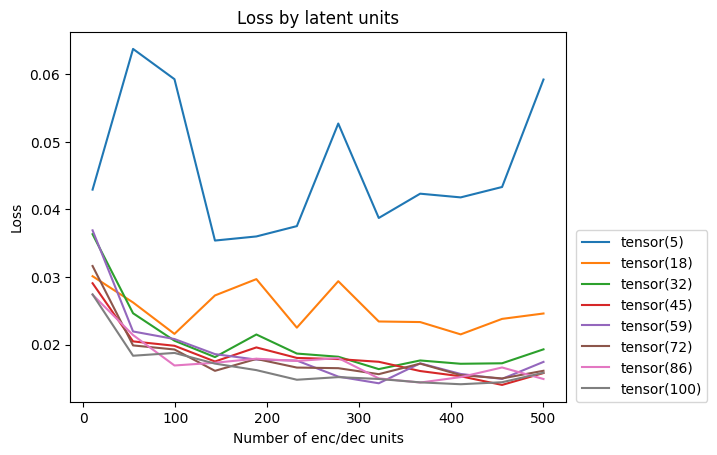

In [76]:
plt.plot(exp_enc_units, losses_store)
plt.legend(exp_lat_units, loc = (1.02,0))
plt.xlabel('Number of enc/dec units')
plt.title('Loss by latent units')
plt.ylabel('Loss')
plt.show()

Similar results show that the more latent units we have, the better the loss looks. However, increasing the number of latent units also raises the risk of overfitting — the model may start reproducing the input almost exactly instead of learning meaningful hidden structures. We also lose the benefit of compression. That’s why we aim for the smallest latent dimension that keeps the loss reasonably low. This way, the model captures the underlying structure of the data without becoming too simple or too memorizing.